In [1]:
# Cell 1 — Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Cell 2 — Load data
df = pd.read_csv("../data/spy_raw.csv", header=[0,1], index_col=0, parse_dates=True)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
print(df.shape)
print(df.head())

(2765, 5)
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  170.125000  171.325815  169.089824  170.911744  121465900
2015-01-05  167.052628  169.247196  166.746219  169.081571  169632600
2015-01-06  165.479141  167.880745  164.684120  167.359012  209151400
2015-01-07  167.541183  167.880724  166.356948  166.804139  125346700
2015-01-08  170.514206  170.729531  168.932466  168.949020  147217800


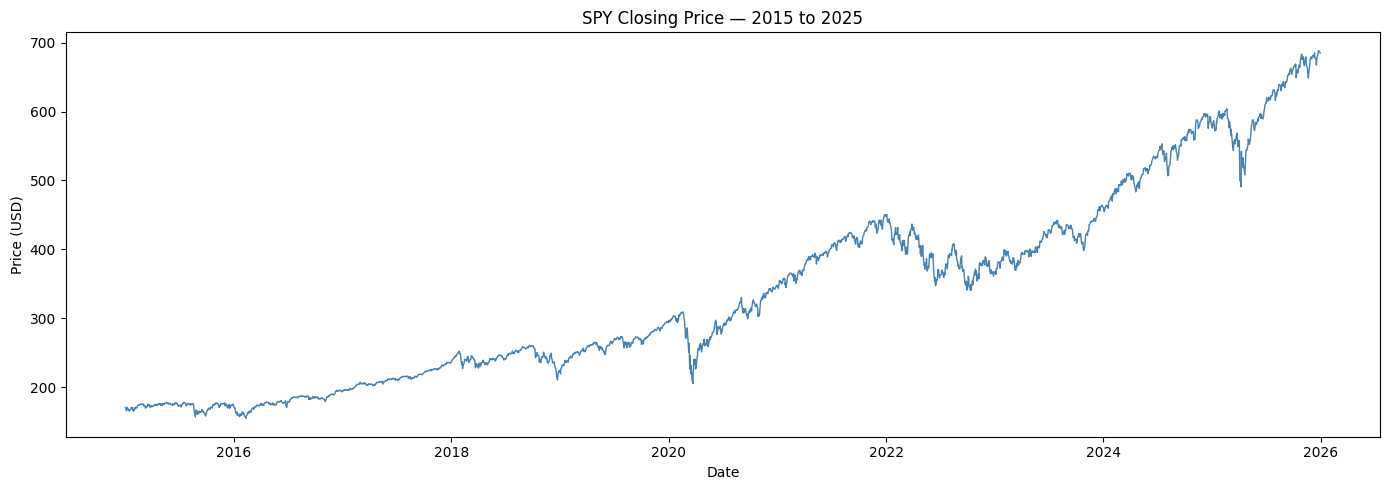

In [3]:
# Cell 3 — Price trend over 10 years
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1)
plt.title('SPY Closing Price — 2015 to 2025')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

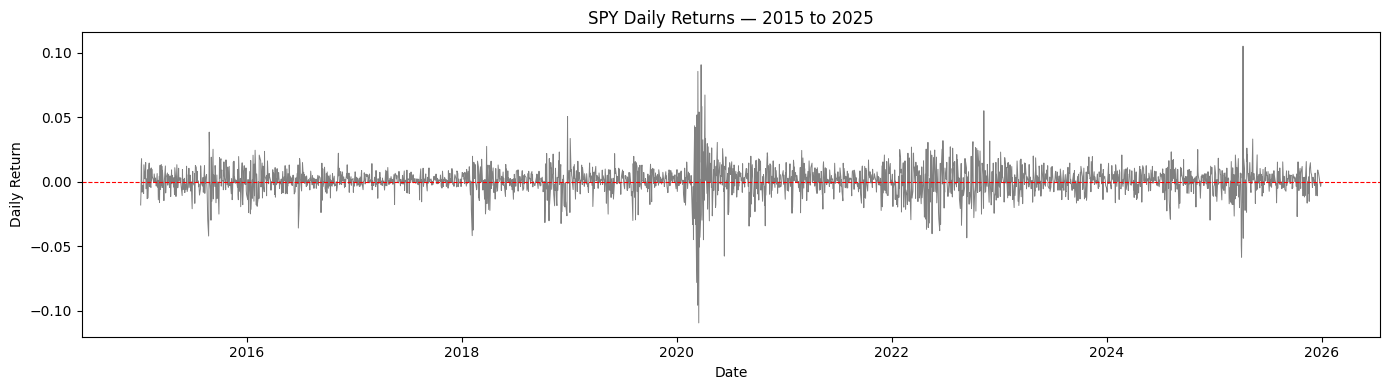

In [4]:
# Cell 4 — Daily returns
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['Daily_Return'], color='gray', linewidth=0.7)
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.title('SPY Daily Returns — 2015 to 2025')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.show()

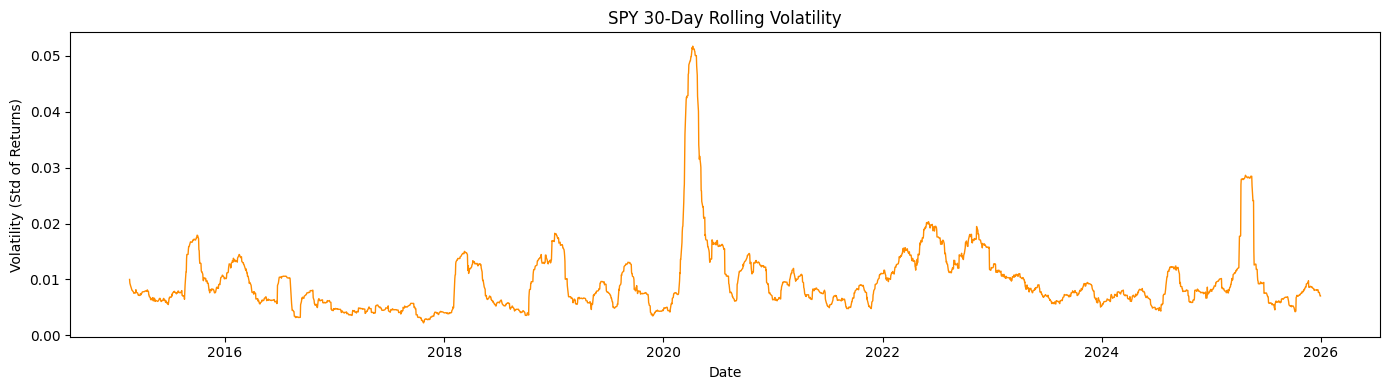

In [5]:
# Cell 5 — Rolling volatility (30-day)
df['Volatility_30'] = df['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['Volatility_30'], color='darkorange', linewidth=1)
plt.title('SPY 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Std of Returns)')
plt.tight_layout()
plt.show()

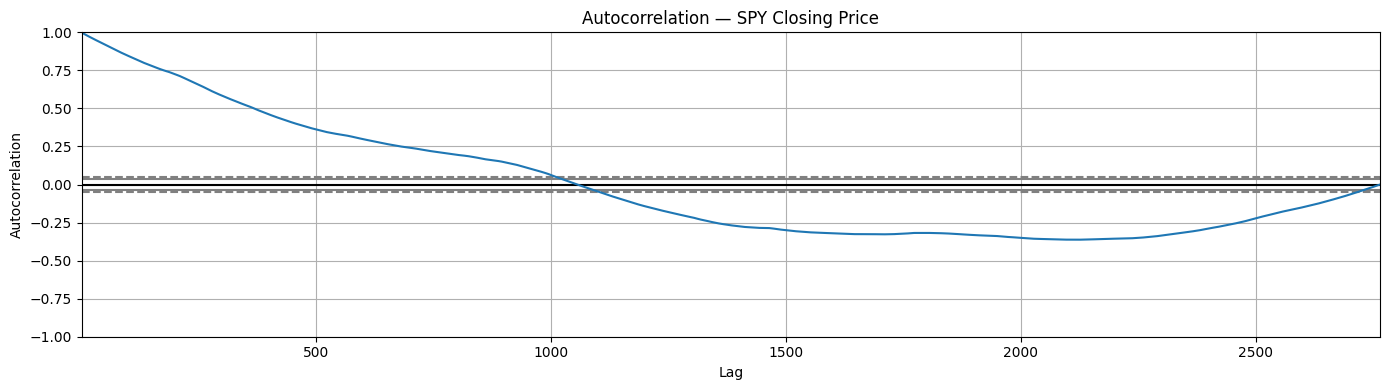

In [6]:
# Cell 6 — Autocorrelation of closing price
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(14, 4))
autocorrelation_plot(df['Close'].dropna())
plt.title('Autocorrelation — SPY Closing Price')
plt.tight_layout()
plt.show()